importing lib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics


In [ ]:
#loading data to a dataframe
gold_data = pd.read_csv("/content/gld_price_data.csv")

# New Section

In [ ]:
#print first 5 rows in the data frame
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
#print last 5 rows
gold_data.tail()


,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [ ]:
#number of rows and columns
gold_data.shape


(2290, 6)

In [ ]:
#getting some basic info about data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
#checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
#getting statstical measures of data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


correlation - positive and negative


In [ ]:
correlation = gold_data.drop('Date', axis=1).corr()

<Axes: >

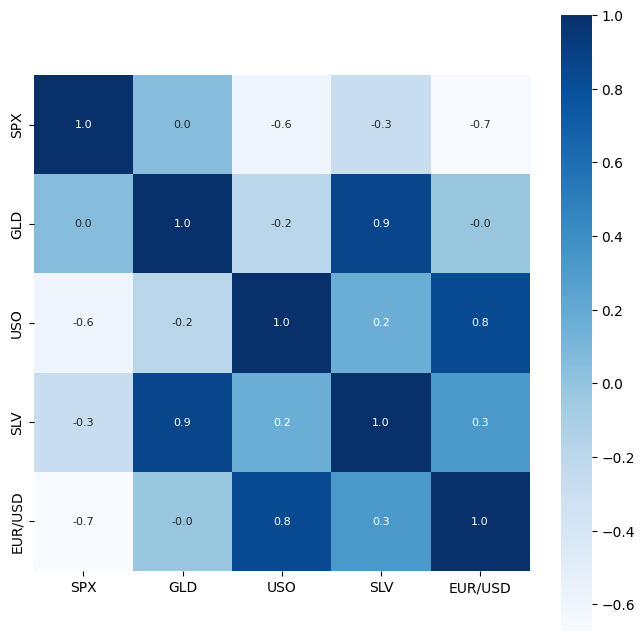

In [ ]:
#constructing heatmap to understand the correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar = True , square= True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [ ]:
#correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


density means number of data points


/tmp/ipython-input-21-971768475.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='blue')


<Axes: xlabel='GLD', ylabel='Density'>

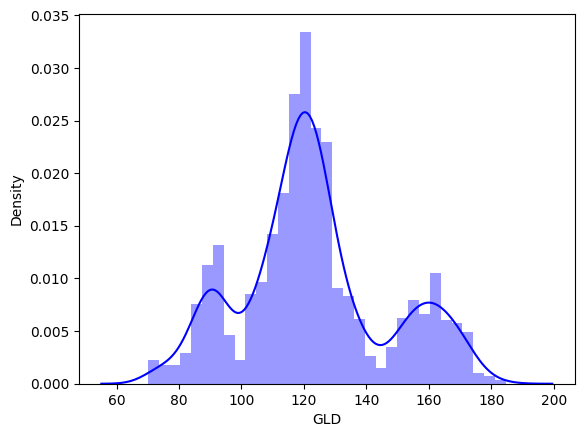

In [ ]:
#checking distribution
sns.distplot(gold_data['GLD'],color='blue')

In [ ]:
X = gold_data.drop(['Date','GLD'],axis = 1)#when you dropping row axis = 0
Y = gold_data['GLD']

In [ ]:
print(X)
print(Y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


splitting into trainig and test data

In [ ]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=2)

random forest model training

In [ ]:
regressor = RandomForestRegressor(n_estimators= 100)


In [ ]:
#training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

In [ ]:
#prediction on test data
test_data_prediction = regressor.predict(X_test)

In [ ]:
print(test_data_prediction)

[168.35759909  81.87259995 115.84499982 127.55770058 120.60270134
 154.88209776 150.50639837 126.14680061 117.37679872 126.03300044
 116.35790136 172.79470046 141.97739824 167.65839943 115.17109998
 117.75150073 139.04650253 170.08370094 159.37540337 161.04289958
 155.13239985 125.43470023 176.74429956 157.29300373 125.24530042
  93.78689954  77.96720005 120.61310003 119.14729934 167.45369948
  88.12770019 125.42710029  91.14160078 117.77749988 121.25019921
 136.22240057 115.5725014  114.88360064 147.59859999 107.26340115
 104.48550251  87.07409778 126.56480061 117.85359992 154.21399901
 119.60710043 108.19760006 108.2044982   93.2211004  126.98709823
  74.37640082 113.71359925 121.43589977 111.3768989  118.90919883
 120.53809975 159.30310005 168.18480176 147.04289671  85.8114985
  94.42850027  86.89409888  90.67020004 118.99740049 126.4302009
 127.61239972 170.33949977 122.22519936 117.5049989   98.76570028
 168.78110185 142.89309763 132.0347029  121.22940225 121.43529946
 119.7647005

In [ ]:
# a R squared error
error_score = metrics.r2_score(Y_test,test_data_prediction)
print("r squared error", error_score)

r squared error 0.9899320264330781


compare the actual and predicted value

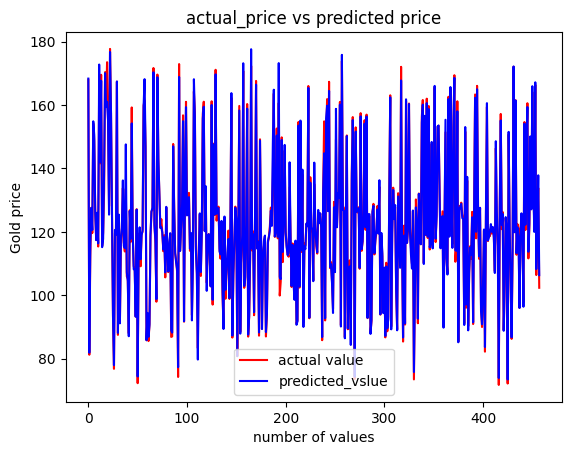

In [ ]:
Y_test= list(Y_test)
plt.plot(Y_test,color = 'red', label= 'actual value')
plt.plot(test_data_prediction,color='blue',label='predicted_vslue')
plt.title('actual_price vs predicted price')
plt.xlabel('number of values')
plt.ylabel('Gold price')
plt.legend()
plt.show()